In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [73]:
data = pd.read_csv(filepath_or_buffer='bank_data.csv', sep=";", header=0)
df = data.copy()
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Предобработка

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


**1. Проверим датасет на наличие пропусков.**

In [77]:
for colum_name in df.columns:
    print(f'В столбце: "{colum_name}", кол-во пропусков = {df[colum_name].isnull().sum()}')

В столбце: "age", кол-во пропусков = 0
В столбце: "job", кол-во пропусков = 0
В столбце: "marital", кол-во пропусков = 0
В столбце: "education", кол-во пропусков = 0
В столбце: "default", кол-во пропусков = 0
В столбце: "balance", кол-во пропусков = 0
В столбце: "housing", кол-во пропусков = 0
В столбце: "loan", кол-во пропусков = 0
В столбце: "contact", кол-во пропусков = 0
В столбце: "day", кол-во пропусков = 0
В столбце: "month", кол-во пропусков = 0
В столбце: "duration", кол-во пропусков = 0
В столбце: "campaign", кол-во пропусков = 0
В столбце: "pdays", кол-во пропусков = 0
В столбце: "previous", кол-во пропусков = 0
В столбце: "poutcome", кол-во пропусков = 0
В столбце: "y", кол-во пропусков = 0
В столбце: "is_default", кол-во пропусков = 0


**2. Проверим датасет на дубликаты.**

In [78]:
df.duplicated().sum() # дубликатов нет

np.int64(0)

**3. Посмотрим на скрытые пропуски unknown**

In [79]:
cols_with_unknown=[]
for col in df.columns:
    if 'unknown' in df[col].unique():
        cols_with_unknown.append(col)
        print(f'Признак {col} содержит скрытые пропуски с процентным соотношением = {round(len(df[df[col]=='unknown'])/len(df)*100,3)} %')

Признак job содержит скрытые пропуски с процентным соотношением = 0.637 %
Признак education содержит скрытые пропуски с процентным соотношением = 4.107 %
Признак contact содержит скрытые пропуски с процентным соотношением = 28.798 %
Признак poutcome содержит скрытые пропуски с процентным соотношением = 81.748 %


В признаках contact и contact достаточно много пропусков. Но тут надо учитывать смысл этих признаков:
- contact описывает способ связи с клиентом (стационарный или мобильный телефон), поэтому unknown это, скорее всего, утерянная информация или запись о старых клиентах, когда не записывались данные о методе связи, поэтому оставим это как категорию
- poutcome показывает, какой результат маркетинга был в прошлый раз для этого клиента - 82% клиентов не участвовали в предыдущей кампании, поэтому это не пропуск, а ценная информация - что мы обрабатываем клиента впервые, поэтому тоже оставим

В остальных же признаках процент unknown слишком мал, поэтому можем оставить.

**4. Для временного анализа приведем month к числовому виду**

In [81]:
df['month'].unique()

<StringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str

In [82]:
df['month_num']=df['month'].map({'may':5, 'jun':6, 'jul':7, 'aug':8, 'oct':10, 'nov':11, 'dec':12, 'jan':1, 'feb':2, 'mar':3, 'apr':4, 'sep':9})

### Визуализация данных

In [60]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous,month_num
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,6.144655
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,2.408034
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,1.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,5.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,6.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,8.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,12.000000


<Axes: title={'center': 'Распределение людей по работе'}, xlabel='job'>

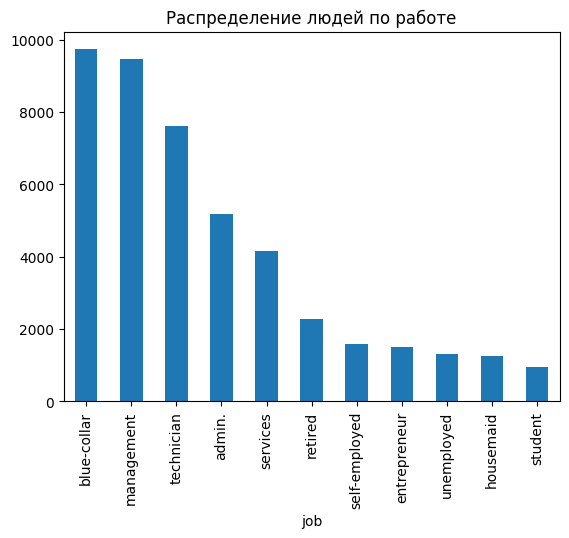

In [61]:
df['job'].value_counts().plot(kind='bar', title='Распределение людей по работе')

<Axes: title={'center': 'Распределение среднего и медианного баланса по работе'}, xlabel='job', ylabel='value (EUR)'>

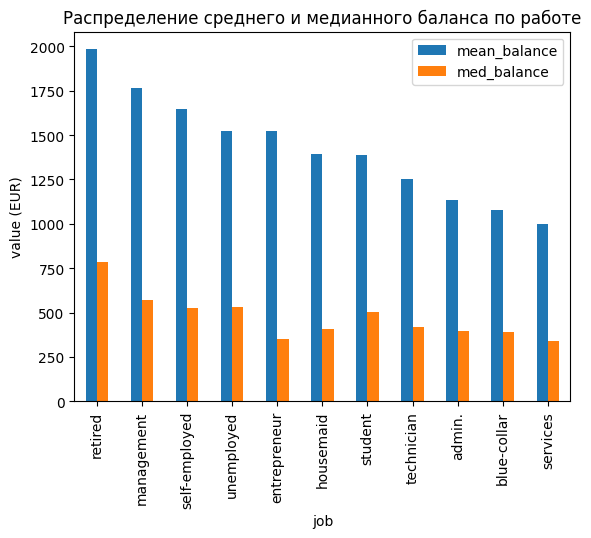

In [62]:
df.groupby(['job']).agg(
    mean_balance=('balance', 'mean'),
    med_balance=('balance', 'median')
    ) \
    .sort_values(by='mean_balance', ascending=False) \
    .plot(kind='bar', ylabel='value (EUR)', title='Распределение среднего и медианного баланса по работе')

<Axes: title={'center': 'Распределение людей по семейному положению'}>

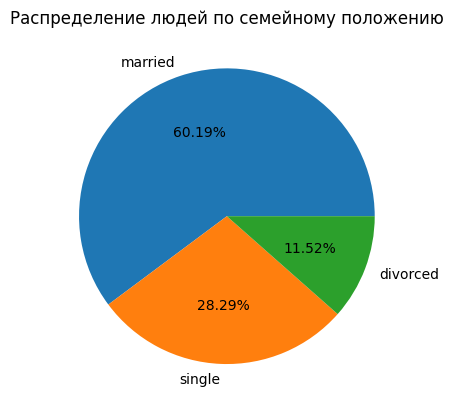

In [63]:
df['marital'].value_counts().plot(kind='pie', autopct=lambda x:'{:.2f}%'.format(x), ylabel='', title='Распределение людей по семейному положению') # https://stackoverflow.com/questions/6170246/how-do-i-use-matplotlib-autopct#:~:text=plt.pie(values%2C%20labels%3Dlabels%2C%20autopct%3Dlambda%20p%20%3A%20%27%7B%3A.2f%7D%25%20%20(%7B%3A%2C.0f%7D)%27.format(p%2Cp%20*%20sum(values)/100))

<Axes: title={'center': 'Распределение людей по уровню образования'}>

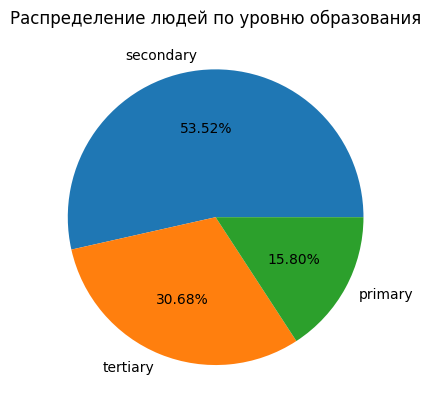

In [64]:
df['education'].value_counts().plot(kind='pie', autopct=lambda x:'{:.2f}%'.format(x), ylabel='', title='Распределение людей по уровню образования')

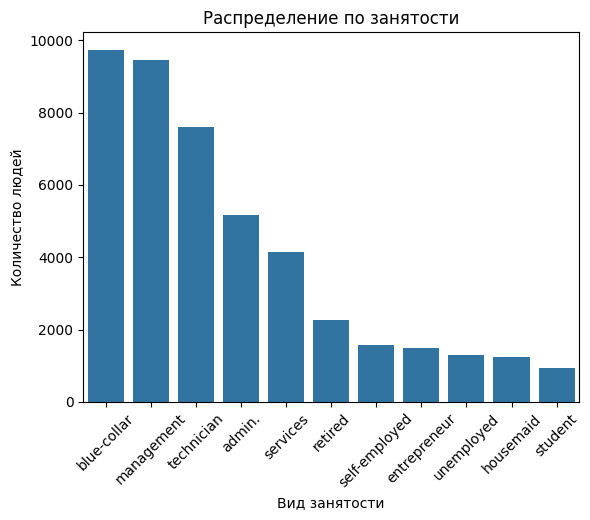

In [86]:
sns.barplot(x=df['job'].value_counts().index, y=df['job'].value_counts().values)
plt.title('Распределение по занятости')
plt.xticks(rotation=45)
plt.xlabel('Вид занятости')
plt.ylabel('Количество людей')
plt.show()

<Axes: title={'center': 'Зависимость ЗП от образования'}, xlabel='education', ylabel='ЗП (EUR)'>

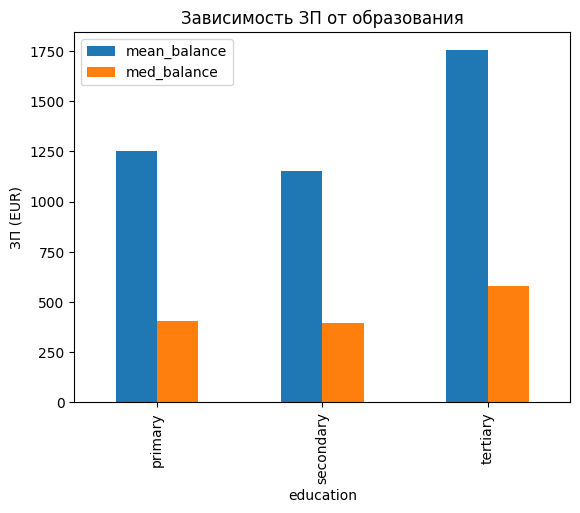

In [65]:
df.groupby(['education']).agg(
    mean_balance=('balance', 'mean'),
    med_balance=('balance', 'median')
).plot(kind='bar', ylabel='ЗП (EUR)', title='Зависимость ЗП от образования')

<Axes: title={'center': 'Распределение наличия просрочки по кредитке у клиентов'}>

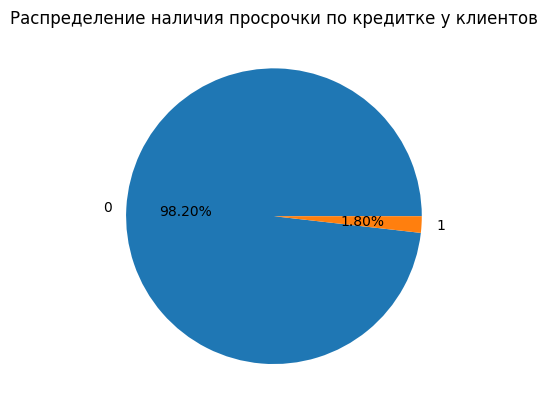

In [75]:
df['is_default'] = df['default'].map({
    'yes': 1,
    'no': 0   
})
df.drop(columns=['default'])
df['is_default'].value_counts().plot(kind='pie', autopct=lambda x:'{:.2f}%'.format(x), ylabel='', title='Распределение наличия просрочки по кредитке у клиентов', labels={'0': 'no', '1': 'yes'})

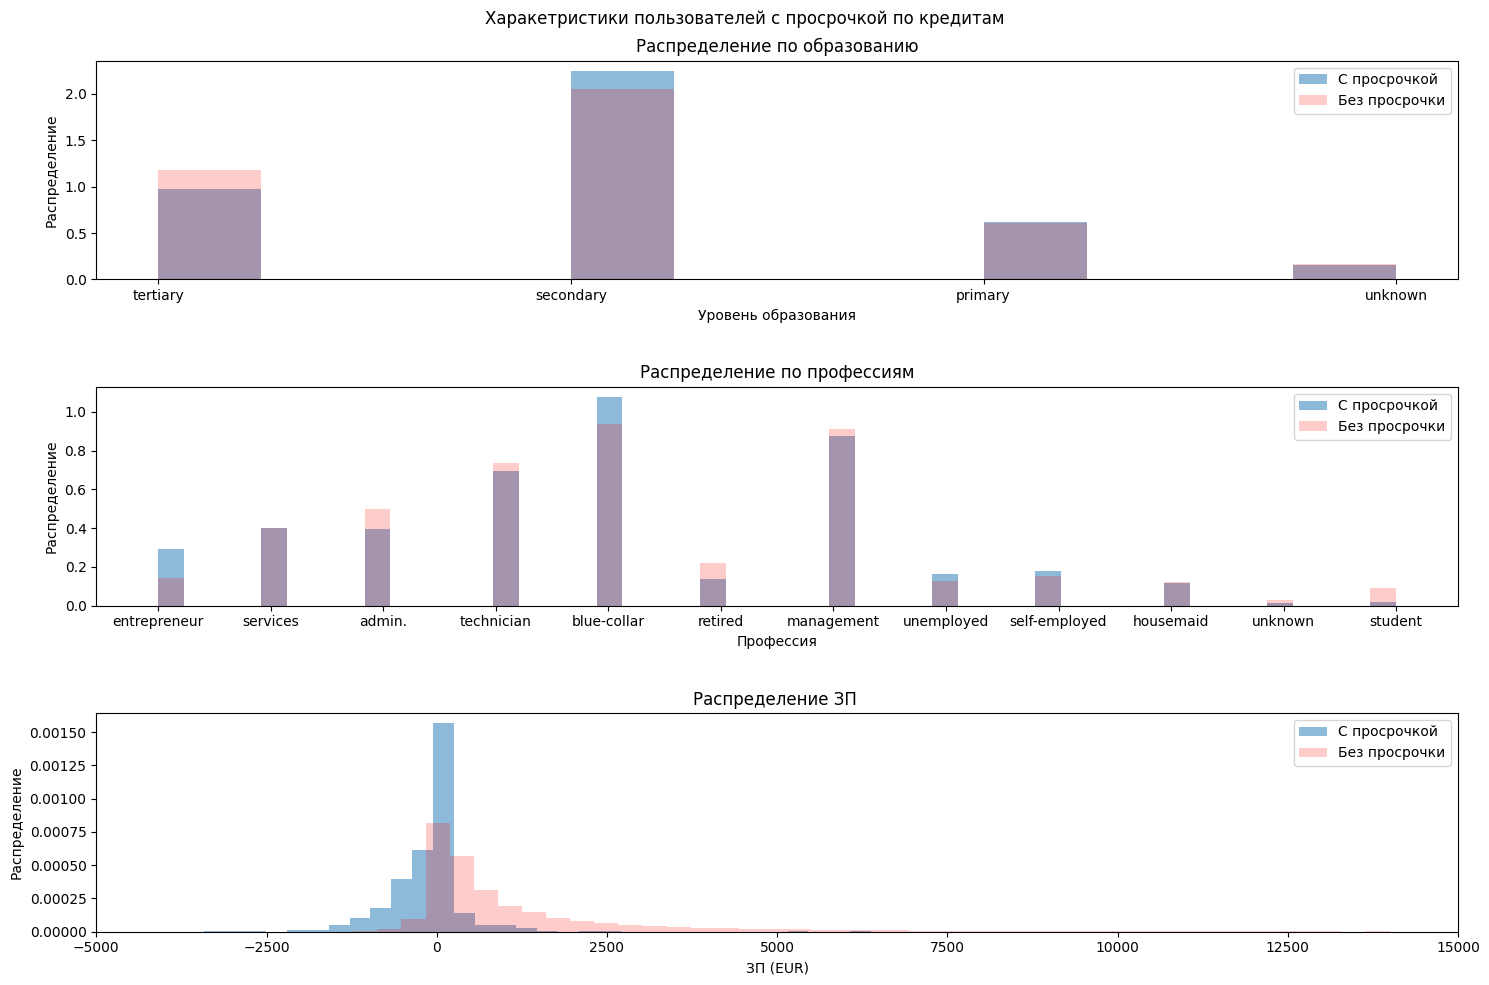

In [76]:
edudef = df[df['is_default'] == 1].groupby('education')['balance'].count()
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10))

ax1.hist(df[df['is_default'] == 1]['education'], alpha=0.5, bins=12, density=True, label='С просрочкой')
ax1.hist(df[df['is_default'] == 0]['education'], alpha=0.2, bins=12, density=True, color='red', label='Без просрочки')
ax1.legend()
ax1.set_title('Распределение по образованию')
ax1.set_xlabel('Уровень образования')
ax1.set_ylabel('Распределение')

ax2.hist(df[df['is_default'] == 1]['job'], alpha=0.5, bins=48, density=True, label='С просрочкой')
ax2.hist(df[df['is_default'] == 0]['job'], alpha=0.2, bins=48, density=True, color='red', label='Без просрочки')
ax2.legend()
ax2.set_title('Распределение по профессиям')
ax2.set_xlabel('Профессия')
ax2.set_ylabel('Распределение')

ax3.hist(df[df['is_default'] == 1]['balance'], alpha=0.5, bins=80, density=True, label='С просрочкой')
ax3.hist(df[df['is_default'] == 0]['balance'], alpha=0.2, bins=300, color='red', density=True, label='Без просрочки')
ax3.set_xlim((-5000, 15000))
ax3.legend()
ax3.set_title('Распределение ЗП ')
ax3.set_xlabel('ЗП (EUR)')
ax3.set_ylabel('Распределение')

fig.suptitle('Харакетристики пользователей с просрочкой по кредитам')

plt.tight_layout(h_pad=3)
plt.show()

**Анализ целевой переменной**

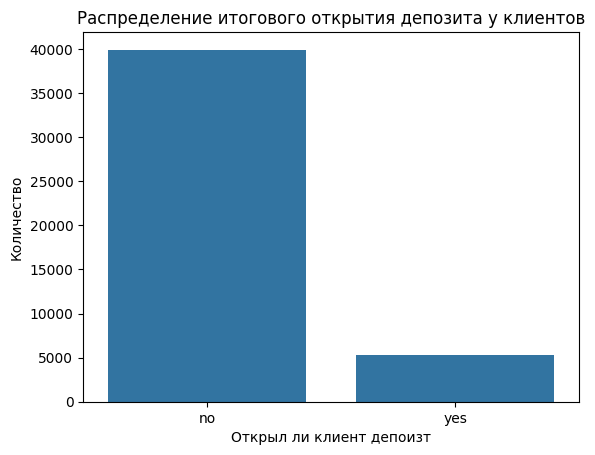

In [49]:
sns.barplot(x=df['y'].value_counts().index, y=df['y'].value_counts().values)
plt.title('Распределение итогового открытия депозита у клиентов')
plt.xlabel('Открыл ли клиент депоизт')
plt.ylabel('Количество')
plt.show()

In [50]:
# также для удобства дальнейшего анализа переведем в числовой вид
df['is_deposit'] = df['y'].map({
    'yes': 1,
    'no': 0   
})
df.drop(columns=['y'])

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,is_deposit,month_num
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0,5
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0,5
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0,5
3,47,blue-collar,married,NaN,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0,5
4,33,NaN,single,NaN,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,1,11
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,1,11
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,1,11
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,0,11


По графику выше (распределение целевой метрики) видно, что наши классы несбалансированы - только 12% людей открыли депозит. Это надо будет учитывать при дальнейшем анализе и выдвижении гипотез

Некоторые выводы

1. Age — возраст
    1. Возраст клиентов в датасете в среднем 41 год — наиболее финансово активное население, что логично
    2. Минимальный возраст — 18 лет, вероятно связано с юр. органичениями
2. Job — категория рабочей деятельности 
    1. ("admin." (администратор, опечатка), "unknown" (неизвестна), "unemployed" (не трудоустроен), "management" (менеджер), "housemaid" (горничная), "entrepreneur" (предприниматель), "student" (студент), "blue-collar" (["синие воротнички"](https://ru.wikipedia.org/wiki/%D0%A1%D0%B8%D0%BD%D0%B8%D0%B9_%D0%B2%D0%BE%D1%80%D0%BE%D1%82%D0%BD%D0%B8%D1%87%D0%BE%D0%BA), рабочий класс ), "self-employed" (самозанятые), "retired" (пенсионеры), "technician" (специалист-технарь), "services" (сфера услуг)) 
    2. В этой переменной есть неизвестная "unknown", заменяю на np.nan
    3. Самые популярные специальности "синий воротничок", технари, менеджеры, администраторы и сфера услуг. 
        2 тысячи человек — пенсионеры
        по 1,5к — самозанятых и предпринемателей
        порядка тысячи человек не трудоустроены, столько же студентов и домработниц
        Ну и люди с неизвестной деятельностью
    4. Интересно посмотреть еще и распределение среднего баланса по категориям:
        Самый большой ср. баланс у пенсионеров — около 2к евро
        Выбивается статус "unkown" — очень высокая медиана и среднее ЗП (возможно, ребята занимаются какой-либо нелегальной деятельностью и т.д.)
        Далее идут менеджеры, самозанятые, нетрудоустроеные (вероятно, находятся на обеспечении / сдают квартиры и тд, поэтому баланс такой большой) и предпринематели. Для предпринемателей интересно заметить, что медианный баланс значительно ниже, чем средний — логично, кто-то успешен, а кто-то нет
        Далее идут студенты и представители среднего класса (домработницы, технари, администраторы, синие воротнички и работники сферы услуг)
3. Marital — семейное положение
    1. Женат (married), Раведен (divorced), Одинок (single). Тут нет никаких 'unknown' и пропусков — это радует
    2. Опять же инетересно посмотреть в разрезе других фичей (работа, возраст)
4. Education — образование
    1. Тут опять же есть unknown(Неизвестно), secondary (Среднее образование (Школа)), tertiary (высшее образование, в португалии к нему относятся универы, колледжи и проф. училища), primary (Начальное образование, 1-4 класс)
    2. Интересно посмотреть как образование влияет на средний счет на балансе
        Интересно, что среднее образование не дает прироста к среднему балансу относительно первичного
        Высшее образование дает значительный прирост к ЗП относительно среднего и первичного образования
        В категории unknown ЗП сравнима с высшим образованием
5. Default — Наличие просрочки по кредиту
    1. Фича на самом деле бинарная, но в датасете дана в формате yes/no, сразу маппим в бинарное числовое представление is_default
    2. Посмотрим, как наличие этого флага влияет на среднюю/медиану ЗП
        Тут же поясню, почему мне всегда интересено влияние фичи на баланс. Наш таргет (NSM РК) — открытие депозитного счета, который непосредственно связан с наличием средств на балансе, так что баланс выступает в роли прокси к целевой метрике
        
        Просрочка по кредиту никак не связана с образованием
        Среди студентов, администраторов и пенсионеров просрочек меньше — такие люди значительно реже берут кредиты
        У предпринемателей, самозанятых, "синих воротничков" и нетрудоустроенных людей просрочек больше: предпринематели и некоторые самозанятые чаще лезут в кредитование, нетрудоустроенные и синие воротнички возможно берут чаще кредиты и не могут их закрыть в силу жизненных сложностей и потребностей больше ЗП
6. Balance — Средний годовой баланс
    1. В балансе интересно смотреть не среднее, а скорее медиану (иначе получится среднее по больнице). В районе 450 EU (согласно метаданным)
    2. Смотрим в разрезе других метрик в другом пункте, основная прокси к депозитному счету 
7. Housing — Есть кредит на дом или нет (бинарная метрика)
8. Loan — Есть кредит под личные нужды
9. Contact — тип маркетинговый коммуникации
10. Day of week — день недели, когда прошла последняя маркетинговая коммуникация
11. Month — последний месяц, когда прошла последняя маркетинговая коммуникация
12. Duration (длительность) — длительность последнего диалога по маркетинговой коммуникации. Важное замечание: этот атрибут сильно влияет на целевой выходной параметр (например, если duration=0, то y='no'). Однако длительность неизвестна до совершения звонка. Кроме того, после завершения звонка значение y становится очевидным. Таким образом, этот входной параметр следует включать только для целей сравнительного анализа и следует отбросить, если цель состоит в создании реалистичной прогностической модели.
13. Сampaign (кампания) — Количество контактов в рамках этой маркетинговой коммуникации на клиента
14. pdays (число дней) — Количество дней, прошедших с момента последнего контакта с клиентом в рамках предыдущей кампании (число; -1 означает, что с клиентом ранее не связывались).
15. previous — число контактов, которые проводили с клиентом до этой маркетинговой кампании
16. poutcome — утилизировался ли клиент от прошлых маркетинговых коммуникаций categorical: 'failure','nonexistent','success'
17. y (целевая метрика) — оформил ли клиент срочный депозит?

## Анализ конверсии